In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

# red wine 품질 등급 예측
```
1. 데이터 셋 확보 & 전처리
     
   결측치 처리 → 독립(입력)변수와 종속(타겟)변수를 분리 → 스케일 조정(StandardScaler)
   → 종속변수의 균형을 확인
   → 종속변수 원핫인코딩(pd.get_dummies) → 훈련셋과 테스트셋분리(train_test_split)  

2. 모델 구성

3. 모델 학습 과정 설정(다중분류)

4. 모델 학습(callbacks, compute_class_weight를 이용)

5. 모델 평가(시각화, 평가, 교차표 - 데스트셋)

6. 모델 저장 및 예측
```

## 1. 데이터셋 확보 및 전처리

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras import metrics
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback, ReduceLROnPlateau
from matplotlib import pyplot as plt

In [8]:
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine.info() # 결측치 없음
# redwine = np.loadtxt('data/winequality-red.csv', delimiter=';', skiprows=1)
# redwine.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [53]:
# 독립(입력)변수와 종속 (타겟)변수를 분리
X_redwine = redwine.iloc[:, :-1].to_numpy() # .values와 유사, numpy로 변경
y_redwine = redwine.iloc[:, -1]
X_redwine.shape, y_redwine.shape

((1599, 11), (1599,))

In [54]:
# 독립변수의 스케일조정
scaler = StandardScaler()
# scaler.fit(X_redwine)
# scaler_X_redwine = scaler.transform(X_redwine)
scaler_X_redwine = scaler.fit_transform(X_redwine)

In [55]:
# 종속변수의 원핫인코딩
Y_redwine = pd.get_dummies(y_redwine).values
np.c_[y_redwine[2:4], Y_redwine[2:4]] # 원데이터와 원핫인코딩

array([[5, 0, 0, 1, 0, 0, 0],
       [6, 0, 0, 0, 1, 0, 0]], dtype=int64)

In [56]:
# 종속변수의 균형을 확인
y_redwine.value_counts(normalize=True)

5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: quality, dtype: float64

In [57]:
# 독립변수와 타겟변수
scaler_X_redwine.shape, Y_redwine.shape

((1599, 11), (1599, 6))

In [58]:
# 훈련셋과 테스트셋 분리(층화추출) = 7:3
X_train, X_test, Y_train, Y_test = train_test_split(scaler_X_redwine,
                                                    Y_redwine,
                                                    test_size=0.3,
                                                    #train_size=0.7,
                                                    stratify=Y_redwine, #층화추출
                                                    random_state=12) #seed값
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1119, 11), (480, 11), (1119, 6), (480, 6))

# 2. 모델구성
- 입력 11 → 64 → 50 → 30 → 6
- He초기화 : 층이 깊을 때 활성화 함수를 relu사용시

In [59]:
model = Sequential(name='sequential')
model.add(Input(11))
model.add(Dense(units=64, activation='relu', kernel_initializer=HeNormal(seed=42)))
model.add(Dense(units=50, activation='relu', kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 64)                768       
                                                                 
 dense_25 (Dense)            (None, 50)                3250      
                                                                 
 dropout_6 (Dropout)         (None, 50)                0         
                                                                 
 dense_26 (Dense)            (None, 30)                1530      
                                                                 
 dense_27 (Dense)            (None, 6)                 186       
                                                                 
Total params: 5,734
Trainable params: 5,734
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [64]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy', 
                      metrics.Recall(name='recall'), 
                      metrics.Precision(name='precision')])

# 4. 학습시키기
- callbacks 이용

In [65]:
%%time
earlyStopping = EarlyStopping(monitor='val_loss', patience=50)
hist = model.fit(X_train, Y_train,
                validation_split=0.2, # 학습셋의 20%를 검증셋으로
                # class_weight=class_weight_dict,
                callbacks=[earlyStopping],
                epochs=200, 
                verbose=2)

Epoch 1/200
28/28 - 3s - loss: 1.6075 - accuracy: 0.3698 - recall: 0.1207 - precision: 0.4303 - val_loss: 1.2925 - val_accuracy: 0.4911 - val_recall: 0.1652 - val_precision: 0.4868 - 3s/epoch - 100ms/step
Epoch 2/200
28/28 - 0s - loss: 1.1997 - accuracy: 0.4927 - recall: 0.2916 - precision: 0.5541 - val_loss: 1.1649 - val_accuracy: 0.5312 - val_recall: 0.3571 - val_precision: 0.6107 - 415ms/epoch - 15ms/step
Epoch 3/200
28/28 - 0s - loss: 1.0745 - accuracy: 0.5765 - recall: 0.3709 - precision: 0.6252 - val_loss: 1.0981 - val_accuracy: 0.5625 - val_recall: 0.3705 - val_precision: 0.6103 - 356ms/epoch - 13ms/step
Epoch 4/200
28/28 - 0s - loss: 1.0394 - accuracy: 0.5944 - recall: 0.4257 - precision: 0.6195 - val_loss: 1.0630 - val_accuracy: 0.5625 - val_recall: 0.3705 - val_precision: 0.6241 - 360ms/epoch - 13ms/step
Epoch 5/200
28/28 - 0s - loss: 0.9989 - accuracy: 0.6101 - recall: 0.4503 - precision: 0.6438 - val_loss: 1.0429 - val_accuracy: 0.5446 - val_recall: 0.4196 - val_precision: 

Epoch 41/200
28/28 - 0s - loss: 0.6218 - accuracy: 0.7430 - recall: 0.6760 - precision: 0.7746 - val_loss: 1.0593 - val_accuracy: 0.5938 - val_recall: 0.5402 - val_precision: 0.6302 - 399ms/epoch - 14ms/step
Epoch 42/200
28/28 - 0s - loss: 0.6107 - accuracy: 0.7564 - recall: 0.7028 - precision: 0.7843 - val_loss: 1.0410 - val_accuracy: 0.5714 - val_recall: 0.5312 - val_precision: 0.6263 - 381ms/epoch - 14ms/step
Epoch 43/200
28/28 - 0s - loss: 0.6123 - accuracy: 0.7453 - recall: 0.6883 - precision: 0.7817 - val_loss: 1.0715 - val_accuracy: 0.5714 - val_recall: 0.5268 - val_precision: 0.6114 - 407ms/epoch - 15ms/step
Epoch 44/200
28/28 - 0s - loss: 0.6014 - accuracy: 0.7475 - recall: 0.6927 - precision: 0.7789 - val_loss: 1.0825 - val_accuracy: 0.5938 - val_recall: 0.5625 - val_precision: 0.6117 - 388ms/epoch - 14ms/step
Epoch 45/200
28/28 - 0s - loss: 0.6116 - accuracy: 0.7430 - recall: 0.6950 - precision: 0.7736 - val_loss: 1.0558 - val_accuracy: 0.6161 - val_recall: 0.5893 - val_prec

# 5. 모델 평가
- 시각화, 평가, 교차표

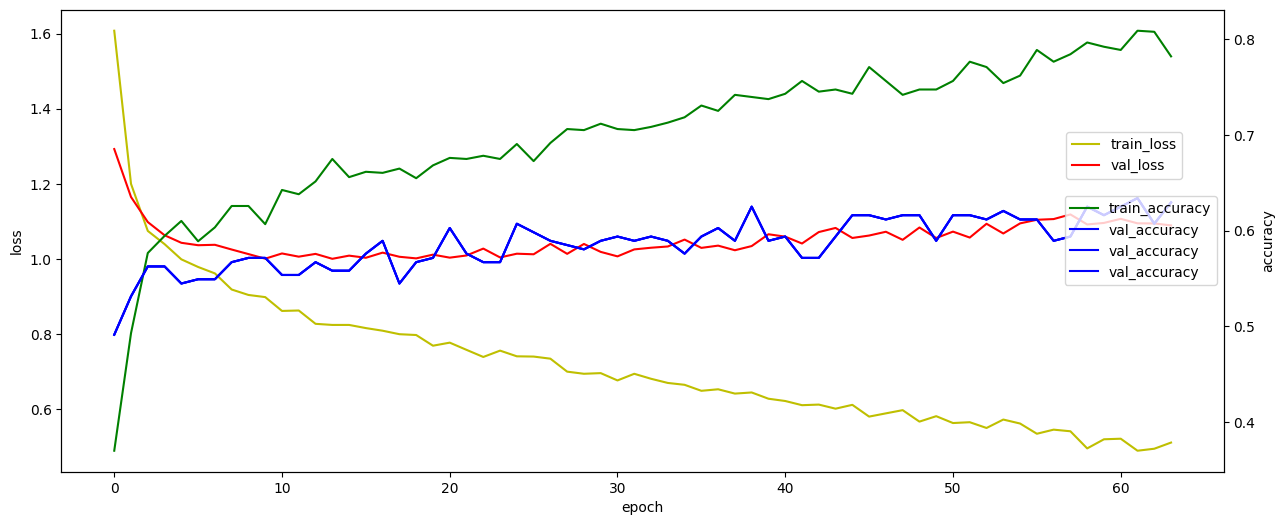

In [66]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [67]:
# 평가
loss, acc, recall, precision = model.evaluate(X_test, Y_test, verbose=0)
print('정확도 :', acc)
print('재현율 :', recall)
print('정밀도 :', precision)

정확도 : 0.643750011920929
재현율 : 0.6020833253860474
정밀도 : 0.6407982110977173


In [68]:
# 교차표를 위한 y_hat
y_hat = model.predict(X_test).argmax(axis=1) + 3
y = Y_test.argmax(axis=1)+3# 실제값
pd.crosstab(y,y_hat, rownames=['실제'], colnames=['예측'])

15/15 [==============================] - 0s 5ms/step


예측,4,5,6,7,8
실제,,,,,
3,0,2,1,0,0
4,0,9,5,2,0
5,1,138,59,6,0
6,1,37,137,17,0
7,0,3,22,34,1
8,0,0,2,3,0


# 6. 모델 사용

In [69]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [70]:
data = [[ 7.4,0.7, 0.,  1.9,  0.076, 11., 34. , 0.9978,  3.51  ,  0.56  ,  9.4   ]]
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1)+3

1/1 [==============================] - 0s 143ms/step


array([5], dtype=int64)